In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10,5)

In [2]:
import os

print(os.getcwd())

C:\Users\ayush


In [3]:
import pandas as pd

df = pd.read_excel("Online Retail.xlsx")

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
print(df.shape)
print(df.columns)
df.head()

(541909, 8)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df.duplicated().sum()

np.int64(5268)

In [9]:
df = df.dropna(subset=['CustomerID'])

In [10]:
df = df[df['Quantity'] > 0]

In [11]:
df = df[df['UnitPrice'] > 0]

In [12]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [13]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


In [14]:
print("Total Revenue:", df['Revenue'].sum())
print("Total Orders:", df['InvoiceNo'].nunique())
print("Total Customers:", df['CustomerID'].nunique())

Total Revenue: 8911407.904
Total Orders: 18532
Total Customers: 4338


In [15]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64


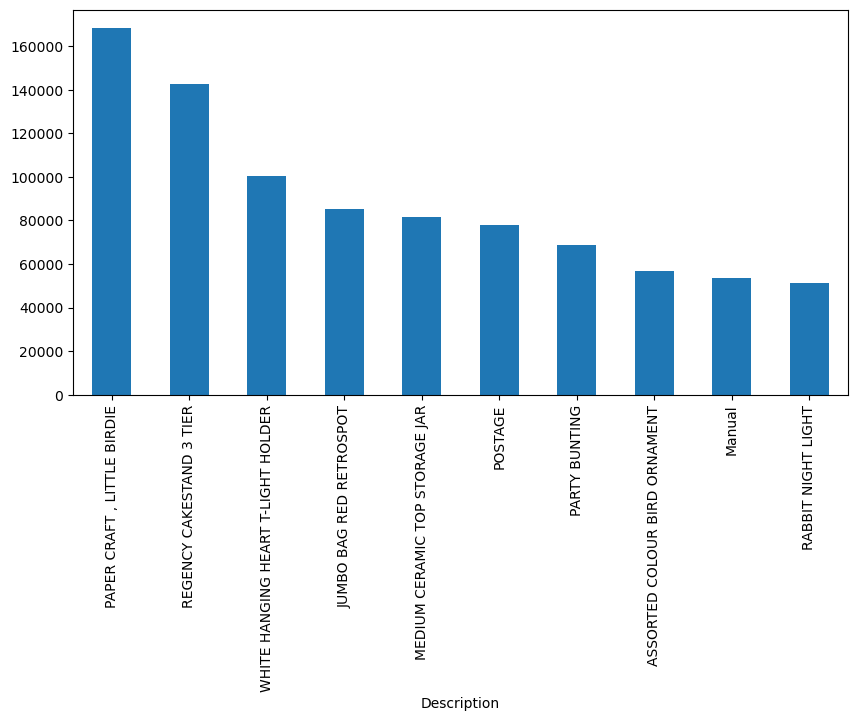

In [16]:
top_products.plot(kind='bar')
plt.show()

In [17]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='object')

In [18]:
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

In [19]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID,Revenue
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [20]:
df.duplicated().sum()

np.int64(5192)

In [21]:
df = df.drop_duplicates()

In [22]:
df.duplicated().sum()

np.int64(0)

In [23]:
print("Total Revenue:", round(df['Revenue'].sum(),2))

Total Revenue: 8887208.89


In [24]:
print("Total Customers:", df['CustomerID'].nunique())

Total Customers: 4338


In [25]:
print("Total Orders:", df['InvoiceNo'].nunique())

Total Orders: 18532


top revenue

In [27]:
top_revenue_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_revenue_products)

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64


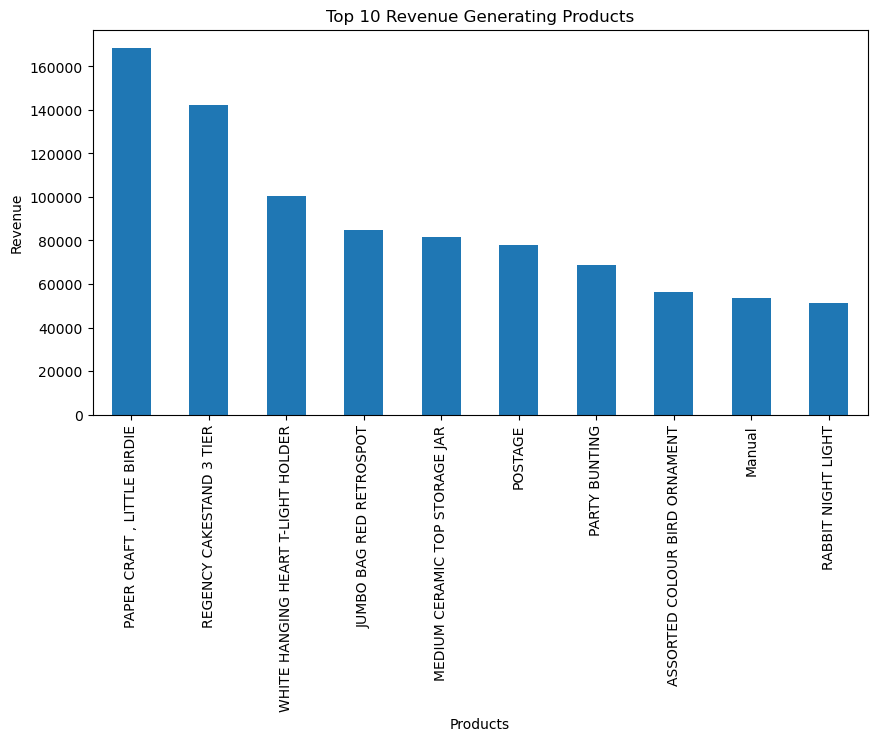

In [57]:
import matplotlib.pyplot as plt
top_revenue_products.plot(kind='bar')
plt.title('Top 10 Revenue Generating Products')
plt.xlabel('Products')
plt.ylabel('Revenue')
plt.savefig("top_revenue_products.png")
plt.show()

Top Selling Products

In [29]:
top_selling_products = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(top_selling_products)

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64


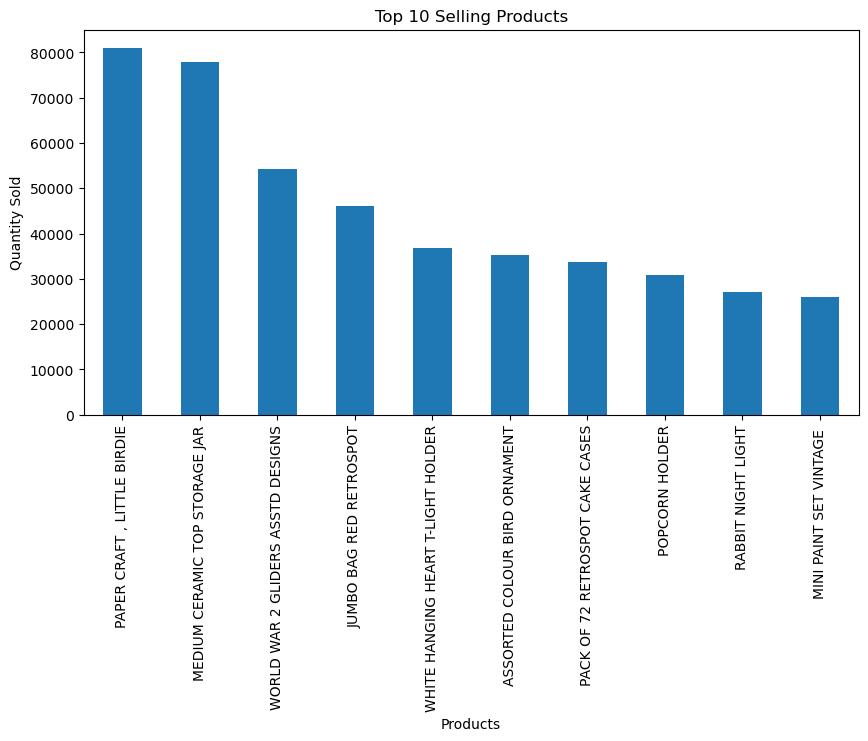

In [59]:
top_selling_products.plot(kind='bar')
plt.title('Top 10 Selling Products')
plt.xlabel('Products')
plt.ylabel('Quantity Sold')
plt.savefig("top_selling_products.png")
plt.show()

Country Analysis

In [31]:
country_sales = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
print(country_sales)

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64


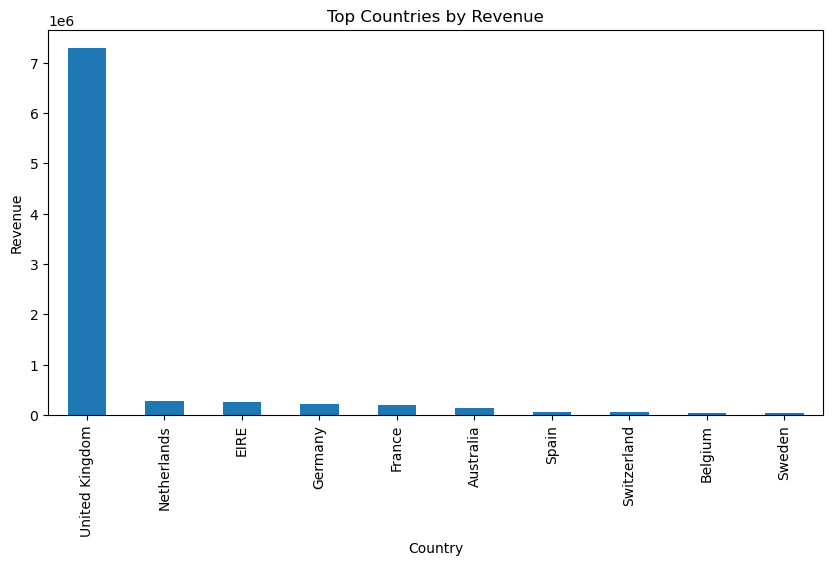

In [60]:
country_sales.plot(kind='bar')
plt.title('Top Countries by Revenue')
plt.xlabel('Country')
plt.ylabel('Revenue')
plt.savefig("country_revenue.png")
plt.show()

Monthly revenue trend

In [33]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = (
    df.groupby('Month')['Revenue']
    .sum()
)
print(monthly_revenue)

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64


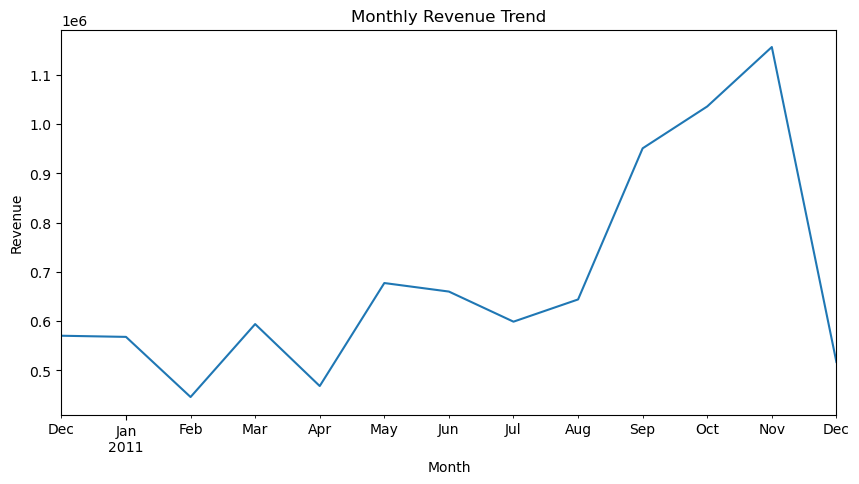

In [61]:
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.savefig("monthly_revenue.png")
plt.show()

Price vs Demand Analysis

In [35]:
price_demand = (
    df.groupby('Description')
    .agg({
        'UnitPrice':'mean',
        'Quantity':'sum'
    })
)
price_demand.head()

,UnitPrice,Quantity
Description,,
4 PURPLE FLOCK DINNER CANDLES,2.312162,138
50'S CHRISTMAS GIFT BAG LARGE,1.248073,1885
DOLLY GIRL BEAKER,1.243704,2394
I LOVE LONDON MINI BACKPACK,4.138406,359
I LOVE LONDON MINI RUCKSACK,4.150000,1


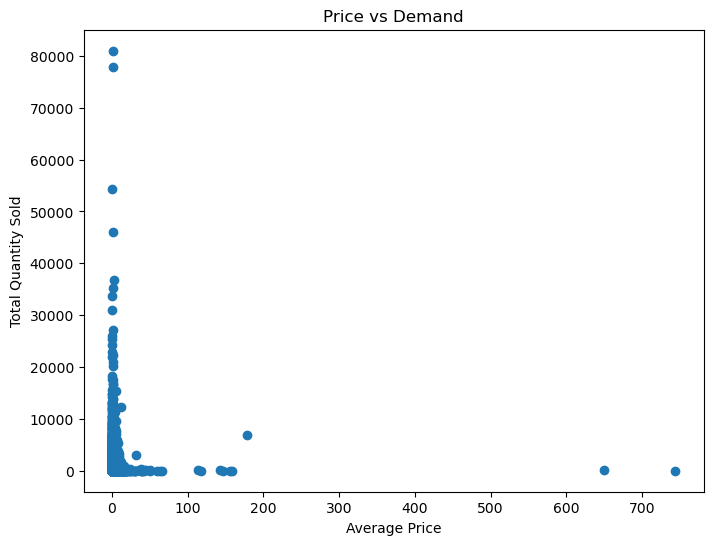

In [62]:
plt.figure(figsize=(8,6))
plt.scatter(
    price_demand['UnitPrice'],
    price_demand['Quantity']
)
plt.xlabel("Average Price")
plt.ylabel("Total Quantity Sold")
plt.title("Price vs Demand")
plt.savefig("price_vs_demand.png")
plt.show()

In [37]:
monthly_revenue

Month
2010-12     570422.730
2011-01     568101.310
2011-02     446084.920
2011-03     594081.760
2011-04     468374.331
2011-05     677355.150
2011-06     660046.050
2011-07     598962.901
2011-08     644051.040
2011-09     950690.202
2011-10    1035642.450
2011-11    1156205.610
2011-12     517190.440
Freq: M, Name: Revenue, dtype: float64

In [38]:
price_demand.head()

,UnitPrice,Quantity
Description,,
4 PURPLE FLOCK DINNER CANDLES,2.312162,138
50'S CHRISTMAS GIFT BAG LARGE,1.248073,1885
DOLLY GIRL BEAKER,1.243704,2394
I LOVE LONDON MINI BACKPACK,4.138406,359
I LOVE LONDON MINI RUCKSACK,4.150000,1


Product summary table


In [39]:
product_summary = (
    df.groupby('Description')
    .agg({
        'UnitPrice':'mean',
        'Quantity':'sum',
        'Revenue':'sum'
    })
)
product_summary.head()

,UnitPrice,Quantity,Revenue
Description,,,
4 PURPLE FLOCK DINNER CANDLES,2.312162,138,265.66
50'S CHRISTMAS GIFT BAG LARGE,1.248073,1885,2272.25
DOLLY GIRL BEAKER,1.243704,2394,2754.50
I LOVE LONDON MINI BACKPACK,4.138406,359,1449.85
I LOVE LONDON MINI RUCKSACK,4.150000,1,4.15


Correlation Between Price and Demand

In [40]:
correlation = product_summary['UnitPrice'].corr(
    product_summary['Quantity']
)

print("Correlation:", correlation)

Correlation: -0.038645649475079355


Revenue leaders

In [41]:
top20 = product_summary.sort_values(
    'Revenue',
    ascending=False
).head(20)
print(top20)

                                     UnitPrice  Quantity    Revenue
Description                                                        
PAPER CRAFT , LITTLE BIRDIE           2.080000     80995  168469.60
REGENCY CAKESTAND 3 TIER             12.482896     12374  142264.75
WHITE HANGING HEART T-LIGHT HOLDER    2.892768     36706  100392.10
JUMBO BAG RED RETROSPOT               2.015969     46078   85040.54
MEDIUM CERAMIC TOP STORAGE JAR        1.220303     77916   81416.73
POSTAGE                              31.570482      3120   77803.96
PARTY BUNTING                         4.876220     15279   68785.23
ASSORTED COLOUR BIRD ORNAMENT         1.680710     35263   56413.03
Manual                              178.406129      6933   53419.93
RABBIT NIGHT LIGHT                    2.012770     27153   51251.24
CHILLI LIGHTS                         5.428445      9646   46265.11
PAPER CHAIN KIT 50'S CHRISTMAS        2.936999     15591   42584.13
PICNIC BASKET WICKER 60 PIECES      649.500000  

Competitor Price Simulation

In [42]:
import numpy as np

product_summary['CompetitorPrice'] = (
    product_summary['UnitPrice']
    * np.random.uniform(
        0.9,
        1.1,
        len(product_summary)
    )
)

In [44]:

product_summary['PriceDifference'] = (
    product_summary['UnitPrice']
    - product_summary['CompetitorPrice']
)

top overpriced products

In [45]:
overpriced = (
    product_summary
    .sort_values(
        'PriceDifference',
        ascending=False
    )
    .head(10)
)

print(overpriced[
    ['UnitPrice',
     'CompetitorPrice',
     'PriceDifference']
])

                                   UnitPrice  CompetitorPrice  PriceDifference
Description                                                                   
DECORATIVE HANGING SHELVING UNIT   59.950000        54.545141         5.404859
BLUE PAINTED KASHMIRI CHAIR        49.950000        45.520871         4.429129
DANISH ROSE BEDSIDE CABINET        39.950000        36.628914         3.321086
VINTAGE BLUE KITCHEN CABINET      146.750000       143.650695         3.099305
CINDERELLA CHANDELIER              43.011364        40.258770         2.752594
MEDINA STAMPED METAL STOOL         39.672222        37.206395         2.465827
BOTANICAL GARDENS WALL CLOCK       24.160000        21.812834         2.347166
UTILTY CABINET WITH HOOKS          21.771667        19.671643         2.100024
HALL CABINET WITH 3 DRAWERS        45.635000        43.768872         1.866128
CREAM SWEETHEART WALL CABINET      18.550000        16.709405         1.840595


discount stratagy

In [46]:
discounts = [0,5,10,15,20]
results = []
for d in discounts:
    new_price = (
        df['UnitPrice']
        * (1-d/100)
    )
    demand_increase = (
        1 + d/50
    )
    new_qty = (
        df['Quantity']
        * demand_increase
    )
    revenue = (
        new_price
        * new_qty
    ).sum()
    results.append(
        [d,revenue]
    )
discount_df = pd.DataFrame(
    results,
    columns=[
        'Discount %',
        'Estimated Revenue'
    ]
)
print(discount_df)

   Discount %  Estimated Revenue
0           0       8.887209e+06
1           5       9.287133e+06
2          10       9.598186e+06
3          15       9.820366e+06
4          20       9.953674e+06


revenue impact

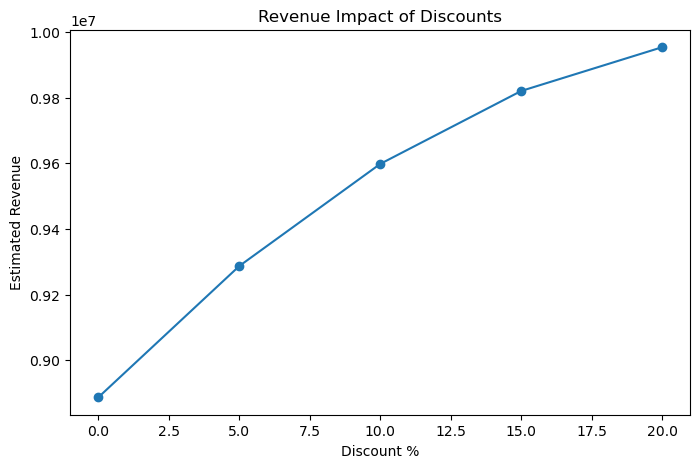

In [64]:
plt.figure(figsize=(8,5))
plt.plot(
    discount_df['Discount %'],
    discount_df['Estimated Revenue'],
    marker='o'
)
plt.title(
    "Revenue Impact of Discounts"
)
plt.xlabel("Discount %")
plt.ylabel(
    "Estimated Revenue"
)
plt.savefig("discount_impact.png")
plt.show()

In [48]:
print("Correlation:", correlation)

Correlation: -0.038645649475079355


In [49]:
discount_df

,Discount %,Estimated Revenue
0,0,8.887209e+06
1,5,9.287133e+06
2,10,9.598186e+06
3,15,9.820366e+06
4,20,9.953674e+06


In [50]:
overpriced.head()

,UnitPrice,Quantity,Revenue,CompetitorPrice,PriceDifference
Description,,,,,
DECORATIVE HANGING SHELVING UNIT,59.950000,6,359.70,54.545141,5.404859
BLUE PAINTED KASHMIRI CHAIR,49.950000,3,149.85,45.520871,4.429129
DANISH ROSE BEDSIDE CABINET,39.950000,13,519.35,36.628914,3.321086
VINTAGE BLUE KITCHEN CABINET,146.750000,26,3685.00,143.650695,3.099305
CINDERELLA CHANDELIER,43.011364,220,3617.60,40.258770,2.752594


Revenue increased under all discount scenarios, with the highest estimated revenue observed at a 20% discount level.

top customers

In [52]:
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64


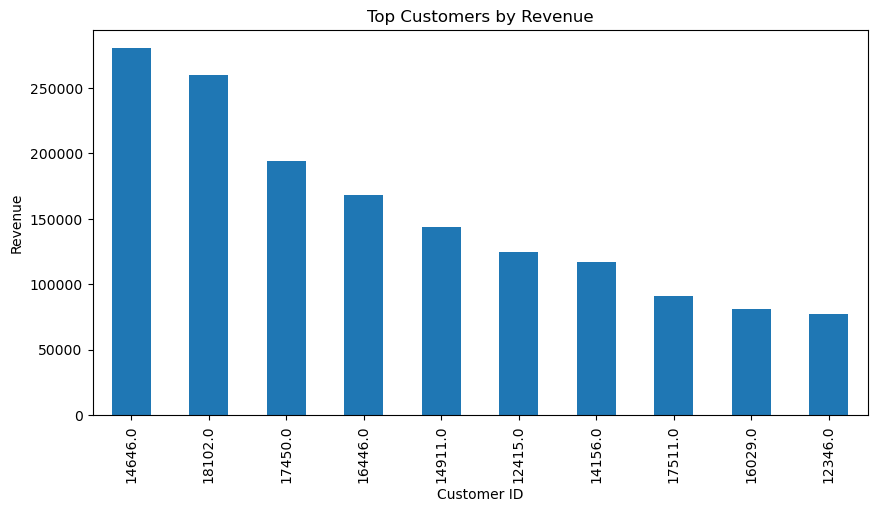

In [53]:
top_customers.plot(kind='bar')
plt.title('Top Customers by Revenue')
plt.xlabel('Customer ID')
plt.ylabel('Revenue')
plt.show()

Monthly Revenue Trend Insights

In [54]:
monthly_revenue.sort_values(
    ascending=False
).head()

Month
2011-11    1156205.610
2011-10    1035642.450
2011-09     950690.202
2011-05     677355.150
2011-06     660046.050
Freq: M, Name: Revenue, dtype: float64

In [55]:
monthly_revenue.sort_values(
    ascending=False
).head()

Month
2011-11    1156205.610
2011-10    1035642.450
2011-09     950690.202
2011-05     677355.150
2011-06     660046.050
Freq: M, Name: Revenue, dtype: float64

In [56]:
top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

In [65]:
import os

files = [f for f in os.listdir() if f.endswith(".png")]
print(files)

['country_revenue.png', 'discount_impact.png', 'monthly_revenue.png', 'price_vs_demand.png', 'top_revenue_products.png', 'top_selling_products.png']


# Business Recommendations

1. Focus inventory and marketing efforts on top revenue generating products.

2. Prioritize the United Kingdom market as it contributes the majority of revenue.

3. Monitor premium-priced products that appear overpriced relative to competitors.

4. Introduce seasonal discount campaigns to improve sales volume.

5. Build loyalty programs targeting high-value customers.

6. Continuously monitor pricing effectiveness and customer demand.